<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Table of Contents:

- [Imports](#imports)
- [Architectural and Performance Decisions](#architectual-and-performance-decisions)
- [Complex Network Feature Engineering](#complex-network-feature-engineering)
- [Initial Data Dictionary](#initial-data-dictionary)
- [Statistical and Associative Data Exploration](#statistical-and-associative-data-exploration)
- [Final Data Dictionary](#final-data-dictionary)

</div>

### ORIENTATION:

This file is intended to make decisions regarding the implementation of mathematic Complex Network ideas as well as their implementation into the 'NF-UQ-NIDS-v2 Network Intrusion Detection Dataset' and exploration of these newly engineered features.

---

### SUMMARY:


<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Imports

- [Back to Table of Contents](#table-of-contents)

</div>

In [2]:
# Largely for re-usable visuals, statistics, and helper functions
import explore_normal_data as eND

# Necessary for Complex Network related functions
import explore_complex_networks as eCN

import numpy as np
import pandas as pd
import networkx as nx
import igraph as ig
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from time import time

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Architectural and Performance Decisions

- [Back to Table of Contents](#table-of-contents)

</div>

##### SUMMARY

- iGraph has faster graph generation

---

##### iGraph vs. NetworkX

In [3]:
df = pd.read_parquet('datasets/clean_short.parquet')

In [29]:
def _nx_graph_generation_time(pdDataFrame: pd.DataFrame,
                              source: str = 'ipv4_src_addr',
                              target: str = 'ipv4_dst_addr',
                              cols_for_edge_weights: list[str] = ['in_bytes', 'out_bytes', 'duration_in'],
                              nodes_to_generate: list[int] = [10, 100, 1000, 10000, 100000, 1000000]) -> dict:
    results = {'sizes': [], 'times': []}
    for total_nodes in nodes_to_generate:
        sample_df = pdDataFrame.head(total_nodes)
        
        start = time()
        # Step 1: Aggregate to collapse parallel edges (Required for DiGraph weights)
        df_weighted = sample_df.groupby([source, target])[cols_for_edge_weights].sum().reset_index()
        
        # Step 2: Create a standard Weighted Directed Graph
        nx_graph = nx.from_pandas_edgelist(
            df=df_weighted,
            source=source,
            target=target,
            edge_attr=cols_for_edge_weights,
            create_using=nx.DiGraph() 
        )
        end = time()
        
        results['sizes'].append(total_nodes)
        results['times'].append(end - start)
    return results

def _ig_graph_generation_time(pdDataFrame: pd.DataFrame,
                              source: str = 'ipv4_src_addr',
                              target: str = 'ipv4_dst_addr',
                              cols_for_edge_weights: list[str] = ['in_bytes', 'out_bytes', 'duration_in'],
                              nodes_to_generate: list[int] = [10, 100, 1000, 10000, 100000, 1000000]) -> dict:
    results = {'sizes': [], 'times': []}
    for total_nodes in nodes_to_generate:
        sample_df = pdDataFrame.head(total_nodes)
        ig_df = sample_df[[source, target] + cols_for_edge_weights]
        
        start = time()
        # Step 1: Create Directed Graph (initializes with multi-edges)
        ig_graph = ig.Graph.DataFrame(ig_df, directed=True, use_vids=False)
        
        # Step 2: Simplify to collapse parallel edges into weights
        # This makes the adjacency matrix identical to the NX version
        ig_graph.simplify(combine_edges={col: "sum" for col in cols_for_edge_weights})
        end = time()
        
        results['sizes'].append(total_nodes)
        results['times'].append(end - start)
    return results

In [30]:
def _vis_graph_generation_time(df, sizes=[10, 100, 1000, 10000, 100000, 1000000]):
    nx_times, ig_times = [], []
    cols = ['in_bytes', 'out_bytes', 'duration_in']
    
    for size in sizes:
        sample = df.head(size)
        
        # Benchmark NetworkX (MultiDiGraph)
        start = time()
        _ = nx.from_pandas_edgelist(sample, 'ipv4_src_addr', 'ipv4_dst_addr', 
                                    edge_attr=cols, create_using=nx.MultiDiGraph())
        nx_times.append(time() - start)
        
        # Benchmark igraph (Directed)
        start = time()
        _ = ig.Graph.DataFrame(sample[['ipv4_src_addr', 'ipv4_dst_addr'] + cols], 
                               directed=True, use_vids=False)
        ig_times.append(time() - start)

    # Convert to arrays for regression
    sizes_arr = np.array(sizes)
    
    # Calculate Best Fit Slopes (y = mx + b)
    m_nx, b_nx = np.polyfit(sizes_arr, nx_times, 1)
    m_ig, b_ig = np.polyfit(sizes_arr, ig_times, 1)

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.scatter(sizes, nx_times, color='red', label='NetworkX Data')
    plt.plot(sizes, m_nx*sizes_arr + b_nx, '--', color='red', label=f'NX Slope: {m_nx:.2e}')
    
    plt.scatter(sizes, ig_times, color='green', label='igraph Data')
    plt.plot(sizes, m_ig*sizes_arr + b_ig, '--', color='green', label=f'IG Slope: {m_ig:.2e}')

    plt.title('Graph Generation Complexity: NX vs igraph')
    plt.xlabel('Number of Edges')
    plt.ylabel('Time (Seconds)')
    plt.legend()
    plt.show()

    print(f"NetworkX Equation: y = {m_nx:.2e}x + {b_nx:.2f}")
    print(f"igraph Equation: y = {m_ig:.2e}x + {b_ig:.2f}")

In [31]:
nx_times = _nx_graph_generation_time(df)
ig_times = _ig_graph_generation_time(df)
print(nx_times)
print(ig_times)

{'sizes': [10, 100, 1000, 10000, 100000, 1000000], 'times': [0.015194177627563477, 0.0070760250091552734, 0.005819082260131836, 0.046385765075683594, 0.08820390701293945, 0.9771959781646729]}
{'sizes': [10, 100, 1000, 10000, 100000, 1000000], 'times': [0.010526895523071289, 0.0053141117095947266, 0.01125192642211914, 0.043740034103393555, 0.25623106956481934, 3.026216983795166]}


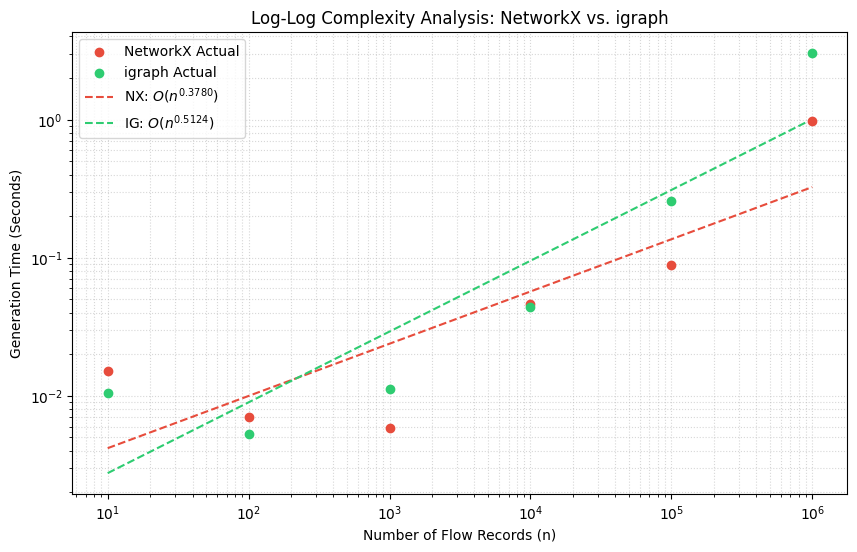

In [32]:
def calculate_big_o(sizes, times):
    # USE LOG10 for consistency with the 10**log_a reconstruction
    log_sizes = np.log10(sizes)
    log_times = np.log10(times)
    
    # b is the slope (the Big O power), log_a is the intercept
    b, log_a = np.polyfit(log_sizes, log_times, 1)
    
    return b, log_a

# 1. Unpack your data (Ensure these are numpy arrays for math operations)
sizes = np.array(nx_times['sizes'])
nx_vals = np.array(nx_times['times'])
ig_vals = np.array(ig_times['times'])

# 2. Calculate
nx_b, nx_log_a = calculate_big_o(sizes, nx_vals)
ig_b, ig_log_a = calculate_big_o(sizes, ig_vals)

# 3. Generate best-fit lines (Reconstructing T = a * n^b)
dense_sizes = np.logspace(np.log10(sizes.min()), np.log10(sizes.max()), 100)
nx_fit = (10**nx_log_a) * (dense_sizes**nx_b)
ig_fit = (10**ig_log_a) * (dense_sizes**ig_b)

# 4. Plotting
plt.figure(figsize=(10, 6))

# Scatter points
plt.scatter(sizes, nx_vals, color='#E74C3C', label='NetworkX Actual', zorder=5)
plt.scatter(sizes, ig_vals, color='#2ECC71', label='igraph Actual', zorder=5)

# Trend lines
plt.plot(dense_sizes, nx_fit, '--', color='#E74C3C', label=f'NX: $O(n^{{{nx_b:.4f}}})$')
plt.plot(dense_sizes, ig_fit, '--', color='#2ECC71', label=f'IG: $O(n^{{{ig_b:.4f}}})$')

plt.xscale('log')
plt.yscale('log')
plt.title('Log-Log Complexity Analysis: NetworkX vs. igraph')
plt.xlabel('Number of Flow Records (n)')
plt.ylabel('Generation Time (Seconds)')
plt.legend()
plt.grid(True, which="both", linestyle=':', alpha=0.5)
plt.show()

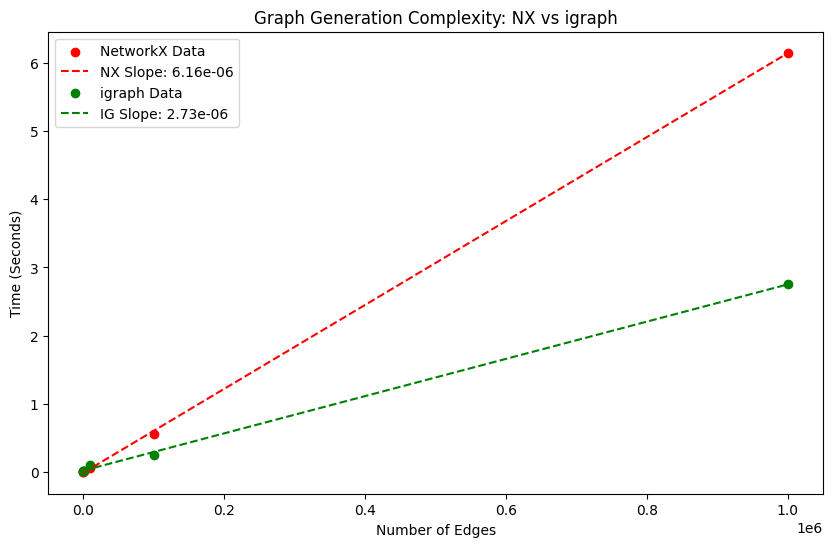

NetworkX Equation: y = 6.16e-06x + -0.01
igraph Equation: y = 2.73e-06x + 0.02


In [33]:
_vis_graph_generation_time(df)

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Complex Network Feature Engineering

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Initial Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Statistical and Associative Data Exploration

- [Back to Table of Contents](#table-of-contents)

</div>

<div style="
    padding: 15px 20px;
    margin: 10px 0;
    border-left: 8px solid #4F7942;
    background-color: rgba(255, 191, 0, 0.05);
    border-radius: 4px;
">

## Final Data Dictionary

- [Back to Table of Contents](#table-of-contents)

</div>